# Customer Segmentation Analysis using Boltzmann Machines on Online Retail Data

---

**Objective:** Build a Restricted Boltzmann Machine (RBM) model that learns hidden patterns in customer purchasing behavior and helps identify customer segments.



## Task 1: Import Libraries

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

# Boltzmann Machine
from sklearn.neural_network import BernoulliRBM

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print("All libraries imported successfully!")

All libraries imported successfully!


## Task 2: Load Dataset

We mount Google Drive and load the Online Retail II Excel dataset.

In [ ]:
# Mount Google Drive (for Google Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset
file_path = '/content/drive/MyDrive/online_retail_II.xlsx'
df = pd.read_excel(file_path)

print(f"Dataset Shape: {df.shape}")
print(f"\nTotal Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
df.head()

Dataset Shape: (525461, 8)

Total Records: 525,461
Total Features: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
# Basic statistics
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


## Task 3: Data Cleaning

We clean the data by removing:
- Missing CustomerID values
- Negative/zero Quantity (returns)
- Cancelled transactions (InvoiceNo starting with 'C')
- Duplicate rows

In [ ]:
print(f"Shape before cleaning: {df.shape}")

# Check missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Rename columns if needed (handle different column name formats)
if 'Customer ID' in df.columns:
    df.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)
if 'Invoice' in df.columns:
    df.rename(columns={'Invoice': 'InvoiceNo'}, inplace=True)
if 'Price' in df.columns:
    df.rename(columns={'Price': 'UnitPrice'}, inplace=True)

# Convert CustomerID to string
df['CustomerID'] = df['CustomerID'].astype(str)

# 1. Remove rows with missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)
print(f"\nAfter removing missing CustomerID: {df.shape}")

# 2. Remove negative or zero Quantity
df = df[df['Quantity'] > 0]
print(f"After removing non-positive Quantity: {df.shape}")

# 3. Remove cancelled transactions (InvoiceNo starting with 'C')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df[~df['InvoiceNo'].str.startswith('C')]
print(f"After removing cancellations: {df.shape}")

# 4. Drop duplicates
df.drop_duplicates(inplace=True)
print(f"After removing duplicates: {df.shape}")

print(f"\n Data cleaning complete!")
print(f"Final dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Shape before cleaning: (525461, 8)

Missing values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

After removing missing CustomerID: (525461, 8)
After removing non-positive Quantity: (513135, 8)
After removing cancellations: (513134, 8)
After removing duplicates: (506293, 8)

 Data cleaning complete!
Final dataset: 506,293 rows x 8 columns


## Task 4: Data Preprocessing

Convert date columns and normalize numerical features.

In [ ]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

# Display cleaned data
df.head()

Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Distribution Plots

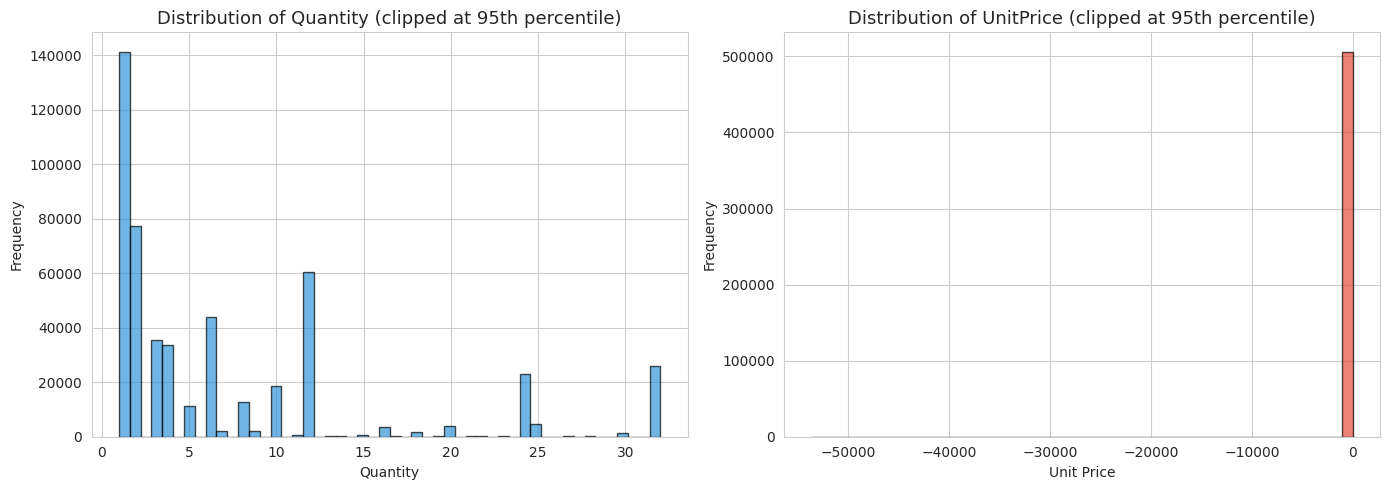

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quantity distribution
axes[0].hist(df['Quantity'].clip(upper=df['Quantity'].quantile(0.95)), bins=50,
             color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Quantity (clipped at 95th percentile)', fontsize=13)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Frequency')

# UnitPrice distribution
axes[1].hist(df['UnitPrice'].clip(upper=df['UnitPrice'].quantile(0.95)), bins=50,
             color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of UnitPrice (clipped at 95th percentile)', fontsize=13)
axes[1].set_xlabel('Unit Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Correlation Heatmap

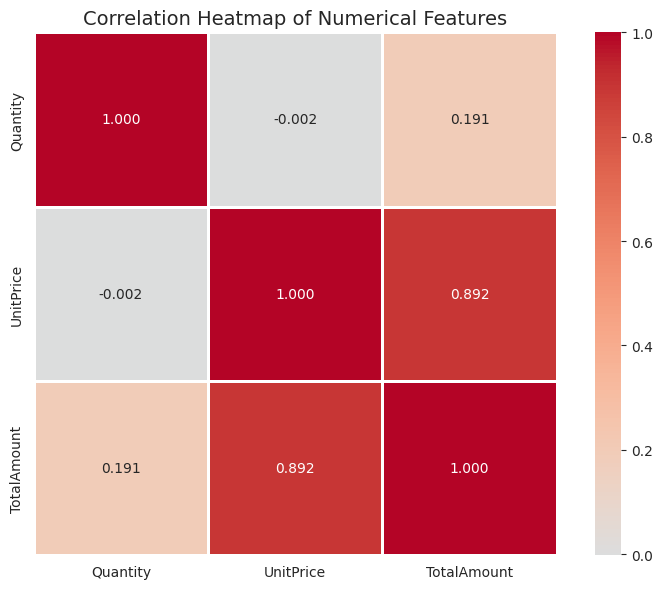

In [ ]:
# Correlation heatmap of numerical features
numerical_cols = df[['Quantity', 'UnitPrice']].copy()
numerical_cols['TotalAmount'] = df['Quantity'] * df['UnitPrice']

plt.figure(figsize=(8, 6))
corr = numerical_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            linewidths=1, square=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Normalize numerical features
scaler = MinMaxScaler()
df[['Quantity_norm', 'UnitPrice_norm']] = scaler.fit_transform(df[['Quantity', 'UnitPrice']])

print("Normalized features added:")
df[['Quantity', 'Quantity_norm', 'UnitPrice', 'UnitPrice_norm']].head(10)

Normalized features added:


,Quantity,Quantity_norm,UnitPrice,UnitPrice_norm
0,12,0.000574,6.95,0.681037
1,12,0.000574,6.75,0.681034
2,12,0.000574,6.75,0.681034
3,48,0.002454,2.10,0.680975
4,24,0.001201,1.25,0.680964
5,24,0.001201,1.65,0.680969
6,24,0.001201,1.25,0.680964
7,10,0.000470,5.95,0.681024
8,12,0.000574,2.55,0.680981
9,12,0.000574,3.75,0.680996


## Task 5: Create Customer-Product Matrix (Pivot Table)

We create a matrix where:
- **Rows** = CustomerID
- **Columns** = StockCode (products)
- **Values** = Quantity purchased

This matrix captures each customer's purchasing behavior across all products.

In [ ]:
# Limit to top N products to keep matrix manageable
top_n = 500
top_products = df['StockCode'].value_counts().head(top_n).index.tolist()
df_filtered = df[df['StockCode'].isin(top_products)]

print(f"Using top {top_n} products")
print(f"Filtered data shape: {df_filtered.shape}")

# Create Customer-Product pivot table
customer_product = df_filtered.pivot_table(
    index='CustomerID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

print(f"\n Customer-Product Matrix Shape: {customer_product.shape}")
print(f"   - {customer_product.shape[0]} customers")
print(f"   - {customer_product.shape[1]} products")
customer_product.head()

Using top 500 products
Filtered data shape: (266576, 10)

 Customer-Product Matrix Shape: (4194, 500)
   - 4194 customers
   - 500 products


StockCode,10002,15036,16237,20675,20676,20677,20679,20681,20682,20685,...,85049E,85061W,85099B,85099C,85099F,85123A,85232B,DOT,M,POST
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
12349.0,0,0,0,0,0,0,0,0,0,10,...,0,0,0,0,0,0,0,0,0,2
12351.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Task 6: Convert to Binary Format


A Restricted Boltzmann Machine (RBM) — specifically `BernoulliRBM` — works with binary (0/1) data. This is because:

1. RBM uses Bernoulli units in its visible layer, which model binary random variables
2. The learning algorithm assumes inputs are probabilities or binary values in [0, 1]
3. Binary representation captures the purchasing pattern (bought vs. not bought) rather than exact quantities
4. This simplification reduces noise and focuses on behavioral patterns

**Transformation rule:**
- If Quantity > 0 → **1** (customer purchased this product)
- If Quantity = 0 → **0** (customer did not purchase this product)

In [ ]:
# Convert to binary format
customer_product_binary = (customer_product > 0).astype(int)

print(f"Binary Matrix Shape: {customer_product_binary.shape}")
print(f"\nValue counts in flattened matrix:")
print(f"  0s (not purchased): {(customer_product_binary.values == 0).sum():,}")
print(f"  1s (purchased):     {(customer_product_binary.values == 1).sum():,}")
print(f"  Sparsity: {(customer_product_binary.values == 0).sum() / customer_product_binary.values.size * 100:.2f}%")

customer_product_binary.head()

Binary Matrix Shape: (4194, 500)

Value counts in flattened matrix:
  0s (not purchased): 1,965,432
  1s (purchased):     131,568
  Sparsity: 93.73%


StockCode,10002,15036,16237,20675,20676,20677,20679,20681,20682,20685,...,85049E,85061W,85099B,85099C,85099F,85123A,85232B,DOT,M,POST
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
12349.0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
12351.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Task 7: Train Restricted Boltzmann Machine (RBM)

The **BernoulliRBM** learns hidden features that capture latent patterns in customer purchasing behavior. The model discovers which products tend to be purchased together and identifies underlying buying patterns.

In [ ]:
# Prepare data for RBM
X = customer_product_binary.values.astype(np.float32)

# Initialize and train RBM
rbm = BernoulliRBM(
    n_components=100,      # Number of hidden units (learned features)
    learning_rate=0.01,    # Learning rate for weight updates
    n_iter=10,             # Number of training epochs
    random_state=42,       # For reproducibility
    verbose=1              # Show training progress
)

# Train the model
print("Training Restricted Boltzmann Machine...")
print("=" * 50)
rbm.fit(X)
print("=" * 50)
print("\n RBM Training Complete!")
print(f"   - Hidden components: {rbm.n_components}")
print(f"   - Input features: {X.shape[1]}")
print(f"   - Training samples: {X.shape[0]}")

Training Restricted Boltzmann Machine...
[BernoulliRBM] Iteration 1, pseudo-likelihood = -108.66, time = 0.38s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -107.65, time = 0.45s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -107.43, time = 0.46s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -106.78, time = 0.45s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -105.77, time = 0.45s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -104.66, time = 0.46s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -103.42, time = 0.45s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -102.47, time = 0.47s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -101.78, time = 0.46s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -101.00, time = 0.45s

 RBM Training Complete!
   - Hidden components: 100
   - Input features: 500
   - Training samples: 4194


## Task 8: Extract Learned Features

The `transform()` method projects each customer into the **hidden feature space**. Each hidden unit captures a latent pattern — for example, a group of products that tend to be bought together.

These learned features serve as a **compressed representation** of customer behavior.

In [ ]:
# Transform data to hidden representation
hidden_features = rbm.transform(X)

print(f"Original data shape:    {X.shape}")
print(f"Hidden features shape:  {hidden_features.shape}")
print(f"\nEach customer is now represented by {hidden_features.shape[1]} learned features.")
print(f"These features capture latent purchasing patterns discovered by the RBM.")

# Create DataFrame with hidden features
hidden_df = pd.DataFrame(hidden_features,
                         index=customer_product_binary.index,
                         columns=[f'Feature_{i+1}' for i in range(hidden_features.shape[1])])
hidden_df.head()

Original data shape:    (4194, 500)
Hidden features shape:  (4194, 100)

Each customer is now represented by 100 learned features.
These features capture latent purchasing patterns discovered by the RBM.


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_91,Feature_92,Feature_93,Feature_94,Feature_95,Feature_96,Feature_97,Feature_98,Feature_99,Feature_100
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0.698275,0.587631,0.784094,0.836570,0.774358,0.697343,0.806210,0.527432,0.750220,0.798490,...,0.641284,0.738137,0.752983,0.648075,0.626708,0.589405,0.718118,0.781730,0.798903,0.519956
12347.0,0.354744,0.812814,0.349967,0.485790,0.608642,0.439504,0.520360,0.288113,0.628487,0.375446,...,0.760602,0.658805,0.608449,0.632791,0.390121,0.788407,0.661426,0.562429,0.660073,0.756808
12348.0,0.493016,0.807494,0.533445,0.654996,0.665709,0.581861,0.689618,0.480374,0.804740,0.485738,...,0.778074,0.737481,0.756838,0.744549,0.542934,0.771025,0.695437,0.692880,0.694862,0.796515
12349.0,0.162719,0.468493,0.293867,0.532863,0.469160,0.213529,0.510457,0.028676,0.377727,0.281725,...,0.445727,0.527240,0.494891,0.329033,0.090957,0.509798,0.435700,0.509312,0.526267,0.338313
12351.0,0.727464,0.749943,0.744908,0.779740,0.788723,0.732067,0.774811,0.660761,0.766705,0.746266,...,0.760582,0.794583,0.787883,0.759623,0.679091,0.752606,0.760791,0.770973,0.783058,0.735687


In [ ]:
# Statistics of hidden features
print("Hidden Feature Statistics:")
print(f"  Mean activation: {hidden_features.mean():.4f}")
print(f"  Min activation:  {hidden_features.min():.4f}")
print(f"  Max activation:  {hidden_features.max():.4f}")
print(f"  Std deviation:   {hidden_features.std():.4f}")

Hidden Feature Statistics:
  Mean activation: 0.5644
  Min activation:  0.0000
  Max activation:  0.9995
  Std deviation:   0.2609


## Task 9: Customer Segmentation using K-Means on RBM Features


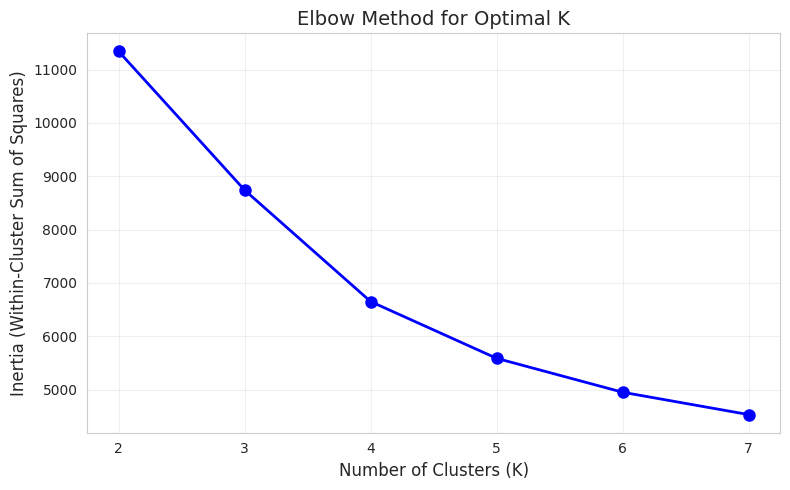

In [ ]:
# Find optimal number of clusters using Elbow Method
inertias = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(hidden_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Apply K-Means with chosen number of clusters
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(hidden_features)

# Add cluster labels to customers
customer_segments = pd.DataFrame({
    'CustomerID': customer_product_binary.index,
    'Cluster': cluster_labels
})

print(f"K-Means Clustering Complete with {n_clusters} clusters!")
print(f"\n Customers per Segment:")
print("=" * 35)
for i in range(n_clusters):
    count = (cluster_labels == i).sum()
    pct = count / len(cluster_labels) * 100
    print(f"  Segment {i}: {count:>5} customers ({pct:.1f}%)")
print("=" * 35)
print(f"  Total:   {len(cluster_labels):>5} customers")

K-Means Clustering Complete with 4 clusters!

 Customers per Segment:
  Segment 0:   510 customers (12.2%)
  Segment 1:  2266 customers (54.0%)
  Segment 2:   663 customers (15.8%)
  Segment 3:   755 customers (18.0%)
  Total:    4194 customers


## Task 10: Output & Visualization

### Customer Segmentation Table

In [ ]:
# Display CustomerID vs Cluster
print("Customer Segmentation Results (first 20 customers):")
print("=" * 40)
print(customer_segments.head(20).to_string(index=False))
print("=" * 40)

Customer Segmentation Results (first 20 customers):
CustomerID  Cluster
   12346.0        1
   12347.0        3
   12348.0        1
   12349.0        3
   12351.0        1
   12352.0        1
   12353.0        1
   12355.0        1
   12356.0        3
   12357.0        0
   12358.0        1
   12359.0        2
   12360.0        3
   12361.0        1
   12362.0        1
   12366.0        1
   12368.0        1
   12369.0        3
   12370.0        1
   12371.0        2


### Cluster Distribution

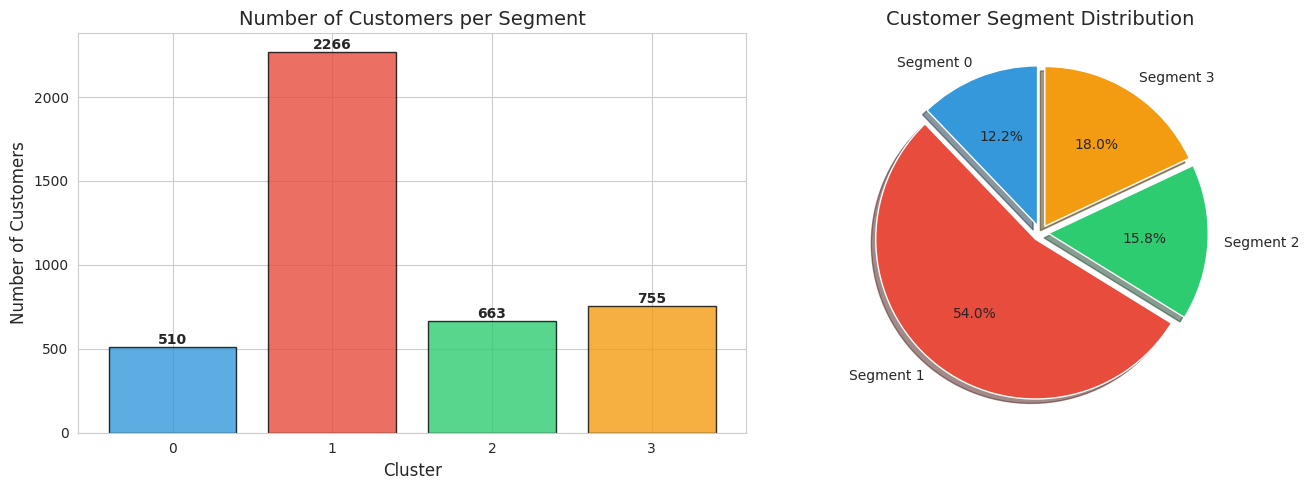

In [ ]:
# Bar chart of cluster sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
axes[0].bar(cluster_counts.index, cluster_counts.values, color=colors[:n_clusters],
            edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)
axes[0].set_title('Number of Customers per Segment', fontsize=14)
axes[0].set_xticks(range(n_clusters))
for i, v in enumerate(cluster_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(cluster_counts.values, labels=[f'Segment {i}' for i in cluster_counts.index],
            colors=colors[:n_clusters], autopct='%1.1f%%', startangle=90,
            explode=[0.05]*n_clusters, shadow=True)
axes[1].set_title('Customer Segment Distribution', fontsize=14)

plt.tight_layout()
plt.show()

### PCA Visualization of Clusters

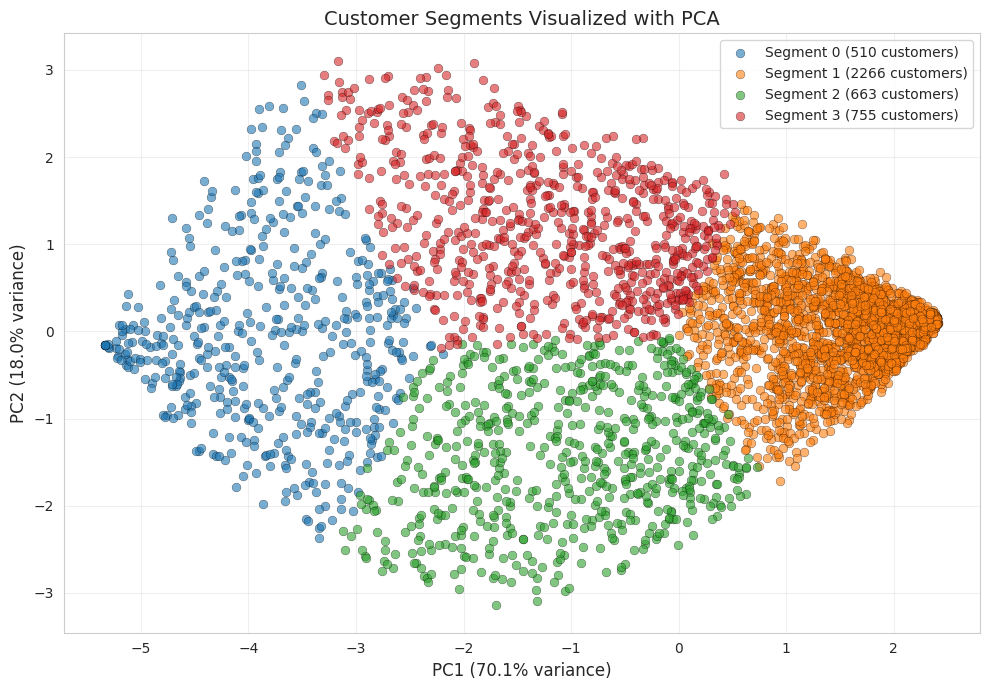

In [ ]:
# Use PCA for better 2D visualization
pca = PCA(n_components=2)
features_2d = pca.fit_transform(hidden_features)

plt.figure(figsize=(10, 7))
for i in range(n_clusters):
    mask = cluster_labels == i
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1],
                label=f'Segment {i} ({mask.sum()} customers)',
                alpha=0.6, s=40, edgecolors='k', linewidth=0.3)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Customer Segments Visualized with PCA', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### RBM Learned Weights Heatmap

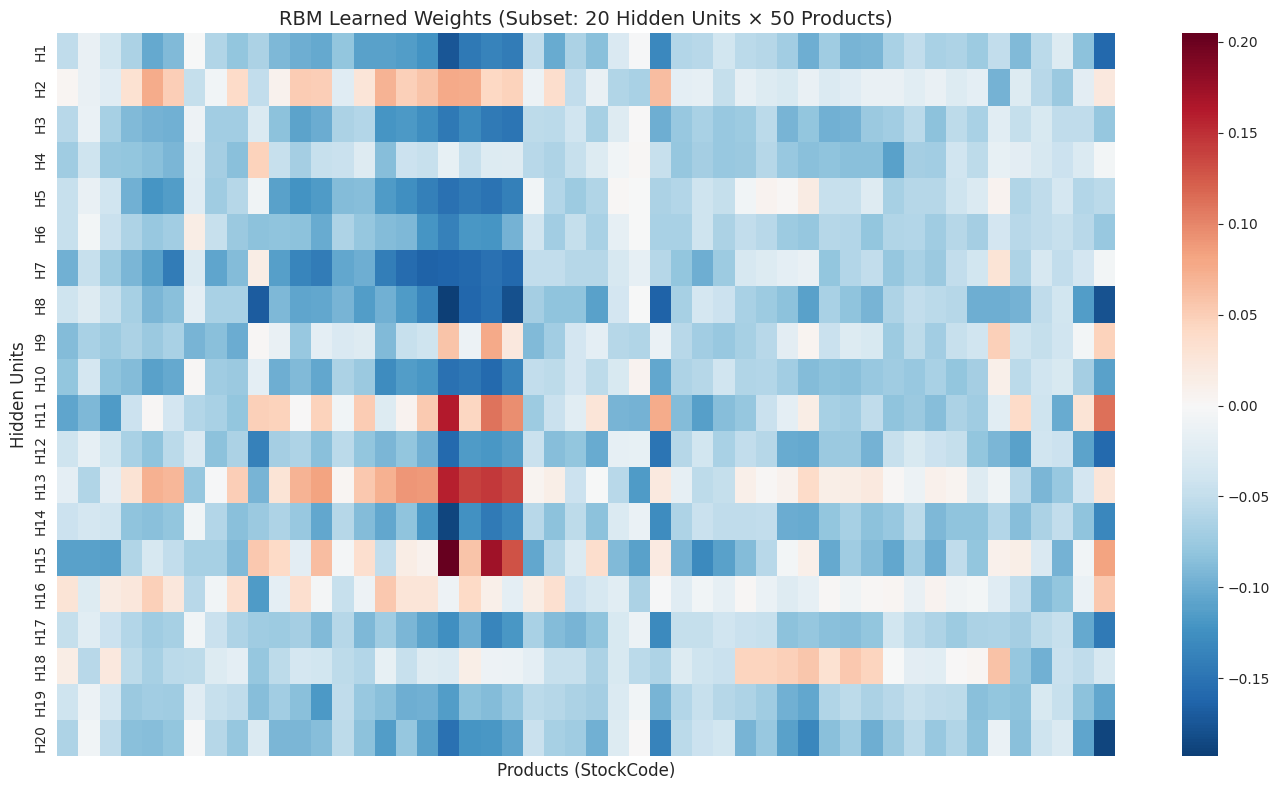

The heatmap shows how each hidden unit responds to different products.
Red = strong positive connection, Blue = strong negative connection.
Clusters of similar colors indicate products the RBM has learned to group together.


In [ ]:
# Visualize a subset of learned weights
plt.figure(figsize=(14, 8))
weights_subset = rbm.components_[:20, :50]  # First 20 hidden units x 50 products
sns.heatmap(weights_subset, cmap='RdBu_r', center=0,
            xticklabels=False, yticklabels=[f'H{i+1}' for i in range(20)])
plt.xlabel('Products (StockCode)', fontsize=12)
plt.ylabel('Hidden Units', fontsize=12)
plt.title('RBM Learned Weights (Subset: 20 Hidden Units × 50 Products)', fontsize=14)
plt.tight_layout()
plt.show()

print("The heatmap shows how each hidden unit responds to different products.")
print("Red = strong positive connection, Blue = strong negative connection.")
print("Clusters of similar colors indicate products the RBM has learned to group together.")

# Task 11: Observations & Conclusions

## What Patterns Did the RBM Learn?
The Restricted Boltzmann Machine (RBM) learned hidden patterns in customer purchases.  
It grouped products that are often bought together.

Each hidden unit represents one type of buying pattern:
- Some patterns show customers who buy kitchen items  
- Some show customers who buy gift or decorative items  
- Some represent seasonal buying behavior  


## How Does Customer Behavior Differ Across Segments?
After applying K-Means clustering:
- Customers are divided into different groups based on their buying habits  
- Some groups contain customers who buy many types of products frequently  
- Other groups contain customers who buy only specific types of products  
- These groups help us understand customer behavior more clearly  

## Model Summary

| Component | Details |
|----------|--------|
| Model | RBM (Restricted Boltzmann Machine) |
| Hidden Units | 100 |
| Learning Rate | 0.01 |
| Training Epochs | 10 |
| Clustering | K-Means (4 clusters) |
| Input | Binary Customer-Product Data |
| Output | Customer Groups based on behavior |

---

## Conclusion
RBM helps in finding hidden patterns in customer data

Combining RBM with K-Means gives clear customer groups

Binary data is important for this model  

This method can be improved by adding more features like purchase time and spending  


